# Linear model selection and model regularization
----
선형모형을 다시 돌아보자.

$$ Y = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p + \epsilon $$

선형모형은 간단함에도 불구하고, interpretablity가 좋고, 종종 좋은 predictive performance를 보인다.

이 장에서는 선형모형의 기본적인 장점은 유지하면서 단점을 보완하는 대안들을 살펴본다.

### Why consider alternatives?

* Prediction accuracy : 만약 $p > n$인 경우, 일반적인 least square estimation을 적용할 수 없다. 추정될 모수의 수를 제한하여 추정량의 분산을 줄이고 예측 정확성을 높인다.

* Model interpretability : 불필요한 feature 변수를 제외하여 모형을 보다 해석 가능하도록 만든다. feature selection 혹은 variable selection이 자동으로 이루어지는 방법에 대해 알아본다.

### 세가지 방법

* Subset selection : $p$개의 predictor 중에서 반응변수와 연관이 있을 것으로 생각되는 부분 집합을 식별하는 방법.

* Shrinkage (regularization) : $p$개의 predictor를 모형 적합에 사용하지만, 그 중의 일부 predictor들의 해당되는 계수는 0 혹은 0과 매우 가까운 값으로 추정된다. 

* Dimension reduction : $p$개의 predictor를 $M$-dimensional subspace로 투영하는 방법.

## Subset selection

$p$개의 predictor가 있을 때, $k=1, 2, \cdots, p$에 대하여 다음을 실행한다.

* 각 $k$에 대하여 정확히 $\binom{p}{k}$개의 가능한 모형이 있다. 이 모형들에 대해 모두 적합을 진행한다.

  * 각 $k$에 대하여 적합된 모형 중 가장 적합이 잘된 모형이 있을 것이다. 이를 $\mathcal M_k$라 하자.
  
  * 한편 predictor가 없는 단순한 평균 모형은 $\mathcal M_0$라고 하겠다.
  
* $\mathcal M_0, \mathcal M_1, \cdots, \mathcal M_p$ 중에서 best인 모형을 찾는다. 

  * Best를 찾기 위해서 cross-validated prediction error, $C_p$ (AIC), BIC 혹은 adjusted $R^2$ 등이 이용될 수 있다.

## Shrinkage methods

적절한 constraint 혹은 regularization 방법을 통해 불필요한 추정치를 0으로 가깝게 만드는 방법이다.

### Ridge regression

Least square 방식을 다시 돌아보자. 이 방법에서는 다음을 최소화하는 다음을 최소화하는 $\beta$들의 값을 찾는다.

$$ \mathrm{RSS} = \sum_{i=1}^{n} \left( y_i - \beta - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 $$

반면 ridge regression에서는 다음을 최소화하는 $\beta$들의 값을 찾는다.

$$ \sum_{i=1}^{n} \left( y_i - \beta - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 = \mathrm{RSS} + \lambda \sum_{j=1}^{p} \beta_j^2 $$

- 여기서 $\lambda \geq 0 $으로 tuning parameter라고 불리운다.

위 식에서 $\beta$들의  추정량을 $\hat \beta^{R}$이라 하겠다.

$\lambda \sum_{j=1}^{p} \beta_j^2$는 shrinkage penalty라고 불리우며, $\beta$들이 0에 가까울수록 작아진다.

적절한 $\lambda$를 선택하는 것이 중요하며 이는 cross-validation 방법을 통해 선택할 수 있다.

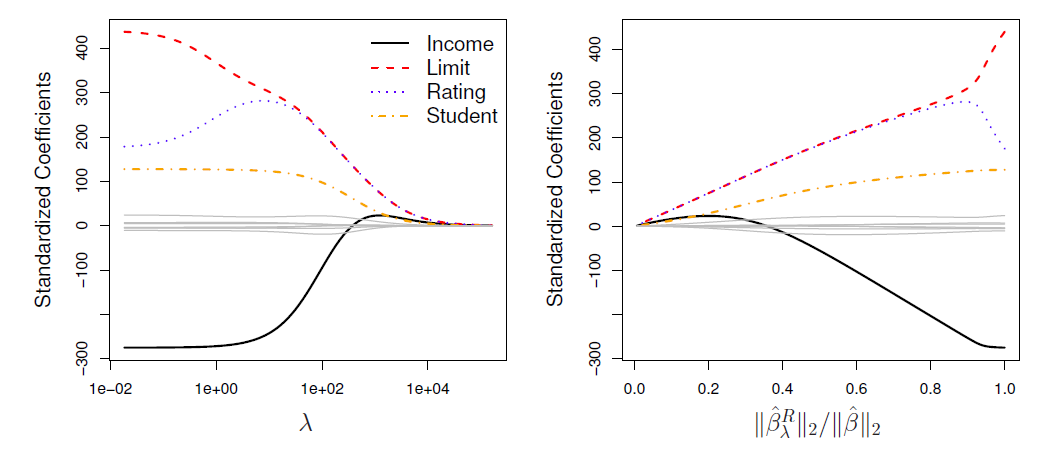

위 그림의 왼쪽에서 보듯 $\lambda$가 커지면 결국 모든 $\beta$들의 추정치는 0에 가까워진다.

오른쪽 그림에서는 x-축에 $ \dfrac{|| \hat \beta_\lambda^R ||_2}{|| \hat \beta ||_2} $를 표현하였다.

여기서 $|| \cdot ||_2$는 $\ell_2$-norm으로서 다음으로 정의한다.

$$ || \beta ||_2 = \sqrt{\sum_{j=1}^{p} \beta_j^2} $$

한편, ridge regression에서는 predictor들을 **표준화**하여 모형을 적합하는 것이 좋다.


$$ \tilde x_{ij} = \frac{x_{ij}}{\sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_{ij} - \bar x_j)^2}} $$

- 정규화는 모든 입력 변수(feature)가 비슷한 스케일일 때 효과적으로 작동하기 때문.

### Bias-variance tradeoff

50개의 데이터와 45개의 predictor를 이용한 시뮬레이션 실험. 실험에서는 모두 non-zero coefficient를 가정하였다.

아래 그림에서 검은 선이 squared bias, 초록색이 variance, test error가 자주색이다.

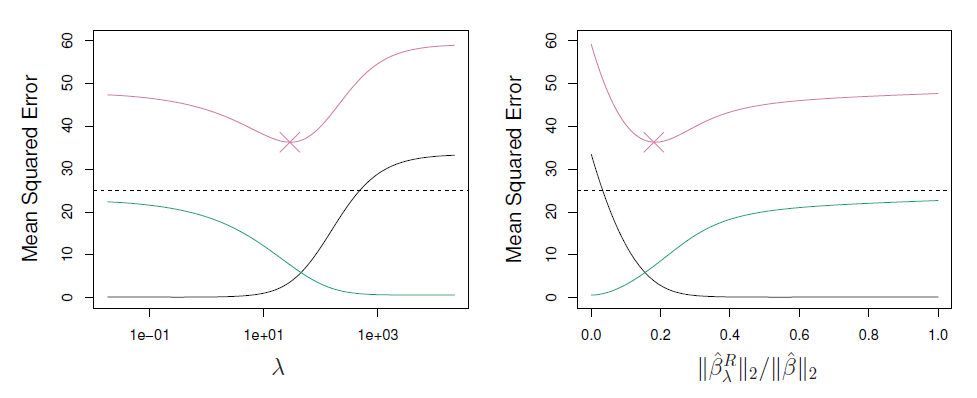

## Lasso 

Ridge regression은 $\lambda$에 따라 coefficient들의 값을 0에 가깝게 보내기는 하지만 완전히 0이 되는 것이 아니기 때문에 최종 모형에는 결국 총 $p$개의 predictor들이 모두 포함된다.

Lasso는 ridge의 대안으로, 다음을 최소화하는 $\beta$들을 찾으며 이를 $\hat \beta_\lambda^L$이라고 하겠다.

$$ \sum_{i=1}^{n} \left( y_i - \beta - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} |\beta_j| = \mathrm{RSS} + \lambda \sum_{j=1}^{p} |\beta_j| $$

통계적 용어로 이야기하자면, lasso는 $\ell_1$ penalty를 사용하고 ridge는 $\ell_2$ penaltiy를 사용하는 것이다.

Ridge와 마찬가지로 lasso 또한 coefficient 추정치를 0으로 보내지만 ridge와 달리 $\lambda$가 충분히 크면 완전히 0의 값이 된다.

따라서 lasso는 일종의 variable selection 역할을 한다.

Lasso는 sparse 모형을 만들어낸다고도 한다.

마찬가지로 적절한 $\lambda$의 값을 선택하는 것이 중요하며 cross-validation 방법이 이용된다.

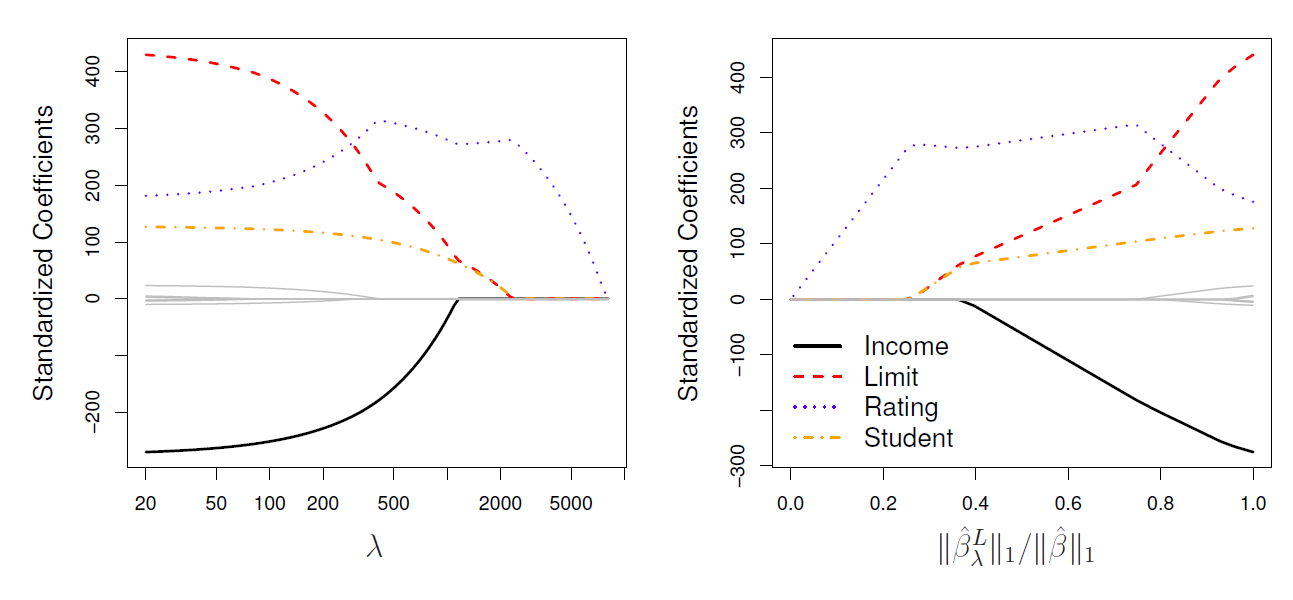

### Ridge와 Lasso의 차이

Lasso와 ridge regression은 각각 결국 다음의 문제를 해결하는 것과 같다.

$$ \arg \min_{\beta} \sum_{i=1}^{n} \left( y_i - \beta - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2  \text{ subject to }  \sum_{j=1}^{p} |\beta_j| \leq s $$

$$ \arg \min_{\beta} \sum_{i=1}^{n} \left( y_i - \beta - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2  \text{ subject to }  \sum_{j=1}^{p} \beta_j^2 \leq s $$

그림으로 표현하자면 다음과 같으며, 단순히 Ridge와 Lasso 중 어느 것이 더 낫다고 결론을 지을 수는 없다.

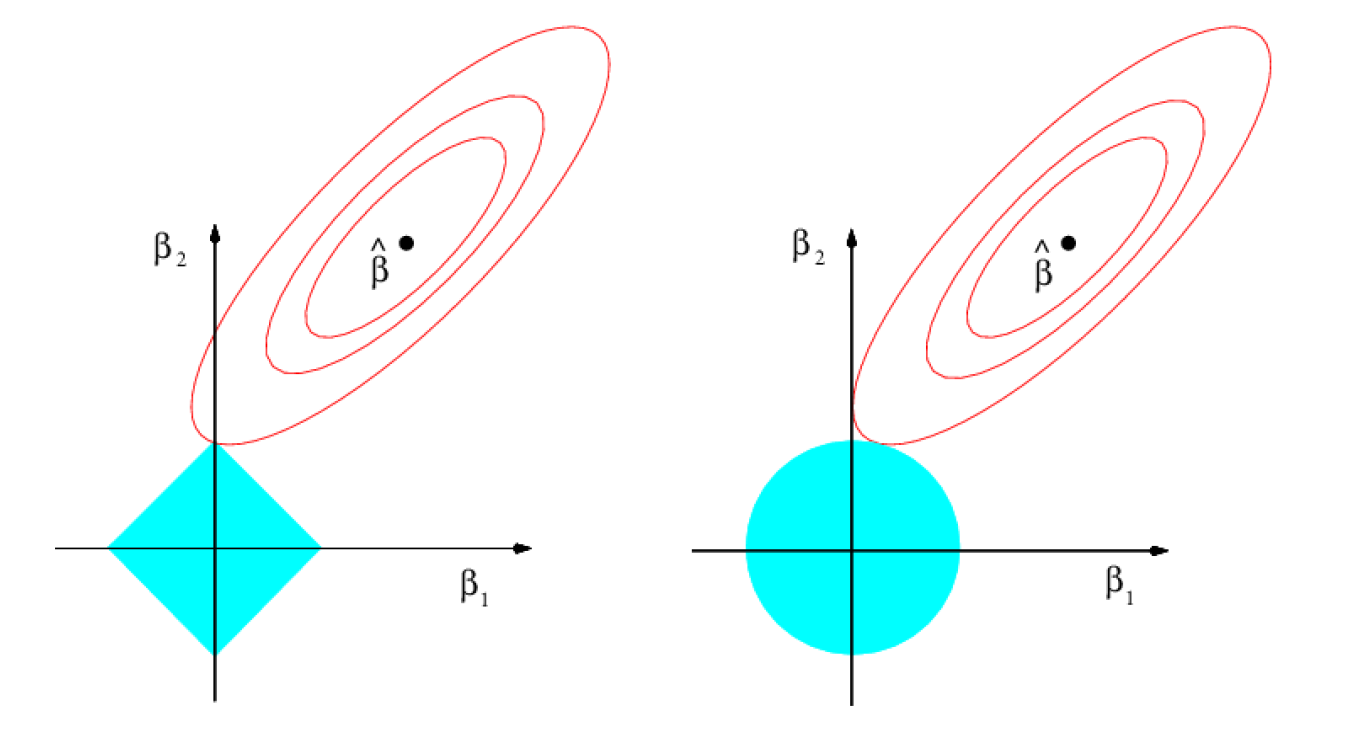

### 모형 선택

앞서 이야기했듯이 $\lambda$는 cross-validation 방법을 통해 정한다.

아래는 ridge regression의 cross-validation 방법을 통해 선택한 $\lambda$의 예제이다.

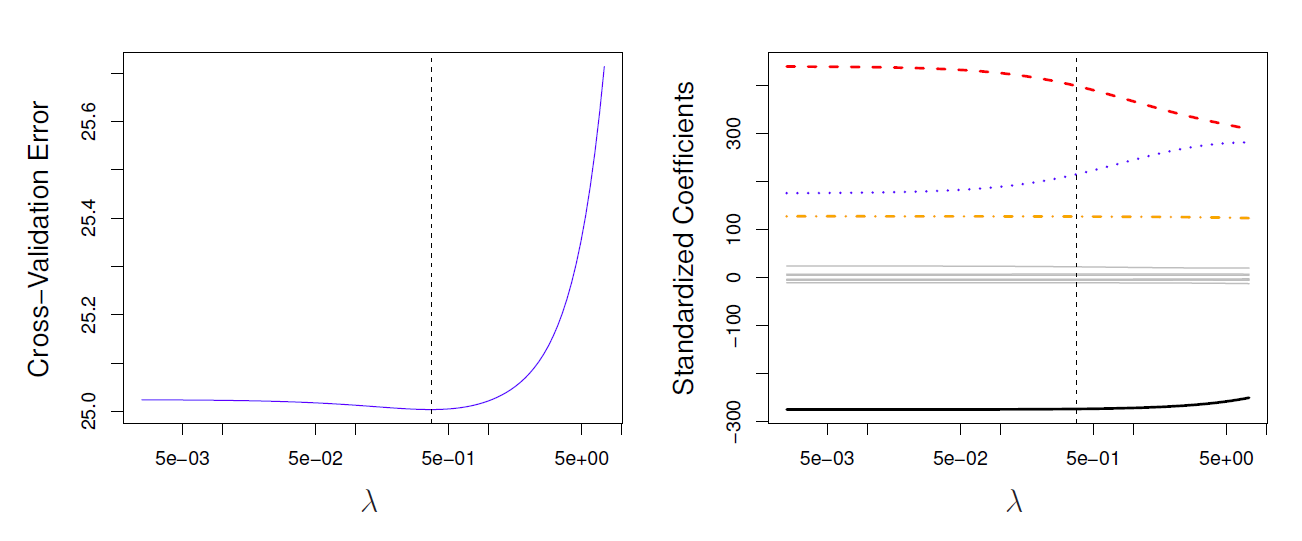

아래는 lasso에서 10-fold cross-validation을 이용하여 $\lambda$의 값을 정하는 예제이다.

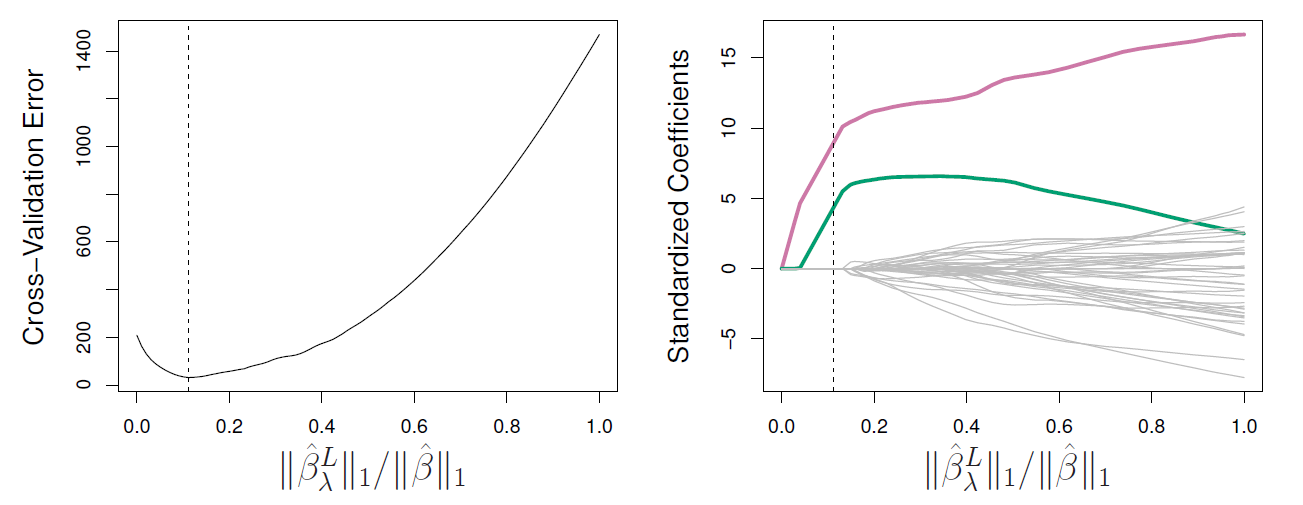

## 엘라스틱넷 (elastic net)

Ridge와 Lasso를 절충한 모델.

그 목적함수는 다음과 같다:

$$
\sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 
+ \lambda \left( r \sum_{j=1}^{p} |\beta_j| + \frac{1 - r}{2} \sum_{j=1}^{p} \beta_j^2 \right)
$$

여기서,

* \$\lambda\$는 **전체 정규화 강도**를 조절하는 하이퍼파라미터이고,
* \$r \in \[0, 1]\$은 **Lasso와 Ridge 사이의 혼합 비율**이다.

  * \$r = 1\$이면 Lasso,
  * \$r = 0\$이면 Ridge,
  * \$0 < r < 1\$이면 두 기법을 혼합한 형태가 된다.


## sklearn 예제

Boston housing dataset

In [1]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

In [2]:
import pandas as pd
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [3]:
pd.DataFrame(y)

,0
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [4]:
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y)

In [5]:
pd.DataFrame(X_tn)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,3.77498,0.0,18.10,0.0,0.655,5.952,84.7,2.8715,24.0,666.0,20.2,22.01,17.15
1,0.11747,12.5,7.87,0.0,0.524,6.009,82.9,6.2267,5.0,311.0,15.2,396.90,13.27
2,10.67180,0.0,18.10,0.0,0.740,6.459,94.8,1.9879,24.0,666.0,20.2,43.06,23.98
3,11.08740,0.0,18.10,0.0,0.718,6.411,100.0,1.8589,24.0,666.0,20.2,318.75,15.02
4,1.34284,0.0,19.58,0.0,0.605,6.066,100.0,1.7573,5.0,403.0,14.7,353.89,6.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,0.84054,0.0,8.14,0.0,0.538,5.599,85.7,4.4546,4.0,307.0,21.0,303.42,16.51
375,38.35180,0.0,18.10,0.0,0.693,5.453,100.0,1.4896,24.0,666.0,20.2,396.90,30.59
376,0.03615,80.0,4.95,0.0,0.411,6.630,23.4,5.1167,4.0,245.0,19.2,396.90,4.70
377,5.70818,0.0,18.10,0.0,0.532,6.750,74.9,3.3317,24.0,666.0,20.2,393.07,7.74


[`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)와 훈련 데이터를 이용하여 표준화를 하겠다.

In [6]:
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)

In [7]:
pd.DataFrame(X_tn_std)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.036832,-0.466391,0.995916,-0.265747,0.863633,-0.493218,0.550785,-0.406482,1.564017,1.459834,0.792147,-3.637368,0.595341
1,-0.418483,0.093763,-0.527251,-0.265747,-0.289722,-0.411440,0.486672,1.232642,-0.560179,-0.621455,-1.514074,0.444327,0.057846
2,0.682833,-0.466391,0.995916,-0.265747,1.611994,0.234173,0.910529,-0.838150,1.564017,1.459834,0.792147,-3.408182,1.541499
3,0.726200,-0.466391,0.995916,-0.265747,1.418301,0.165308,1.095743,-0.901170,1.564017,1.459834,0.792147,-0.406548,0.300273
4,-0.290619,-0.466391,1.216277,-0.265747,0.423421,-0.329662,1.095743,-0.950805,-0.560179,-0.082079,-1.744696,-0.023953,-0.889697
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,-0.343032,-0.466391,-0.487050,-0.265747,-0.166463,-0.999665,0.586403,0.366914,-0.671979,-0.644907,1.161143,-0.573456,0.506682
375,3.571166,-0.466391,0.995916,-0.265747,1.198195,-1.209131,1.095743,-1.081585,1.564017,1.459834,0.792147,0.444327,2.457181
376,-0.426968,3.118592,-0.962017,-0.265747,-1.284602,0.479507,-1.632610,0.690371,-0.671979,-1.008399,0.330903,0.444327,-1.129353
377,0.164893,-0.466391,0.995916,-0.265747,-0.219288,0.651670,0.201727,-0.181659,1.564017,1.459834,0.792147,0.402627,-0.708223


In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_tn_std, y_tn)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-1.05, 0.83, 0. ,...,-2.12, 0.8 ,-3.49]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.41
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[48.4 ,23.01,21.45,..., 8.26, 7.95, 4.45]"


In [9]:
print(lr.coef_, lr.intercept_)

[-1.04733176e+00  8.28710980e-01  2.15881058e-03  6.73245117e-01
 -1.96322343e+00  2.86430094e+00  8.48893932e-02 -2.81274837e+00
  2.63423841e+00 -2.06276332e+00 -2.12410493e+00  8.03406822e-01
 -3.49055327e+00] 22.412137203166264


### sklearn에서의 Ridge, Lasso regression

[```sklearn.linear_model.Ridge```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

minimize ```||y - Xw||^2_2 + alpha * ||w||^2_2```

In [10]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1)   
ridge.fit(X_tn_std, y_tn)
print(ridge.coef_, ridge.intercept_)

[-1.03548578  0.80360393 -0.03187945  0.67942487 -1.92513246  2.87483261
  0.07547559 -2.77423913  2.52326857 -1.95434599 -2.11427711  0.80248206
 -3.47576382] 22.412137203166264


다양한 튜닝 파라미터 `alpha`에 대해 진행해 보자.

In [11]:
import numpy as np
from sklearn.metrics import mean_squared_error

alphas = np.array([0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000])

coefs = []
errs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_tn_std, y_tn)
    coefs.append(ridge.coef_)
    errs.append(mean_squared_error(y_te, ridge.predict(X_te_std)))

In [12]:
pd.DataFrame(coefs)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-1.047209,0.828449,0.001800,0.673310,-1.962833,2.864411,0.084792,-2.812356,2.633076,-2.061621,-2.124005,0.803398,-3.490403
1,-1.046109,0.826105,-0.001413,0.673893,-1.959330,2.865400,0.083918,-2.808831,2.622667,-2.051394,-2.123106,0.803314,-3.489054
2,-1.041305,0.815898,-0.015317,0.676416,-1.943948,2.869692,0.080102,-2.793310,2.577460,-2.007118,-2.119147,0.802944,-3.483104
3,-1.035486,0.803604,-0.031879,0.679425,-1.925132,2.874833,0.075476,-2.774239,2.523269,-1.954346,-2.114277,0.802482,-3.475764
4,-0.995080,0.720469,-0.138285,0.698830,-1.788966,2.908447,0.043292,-2.633321,2.164272,-1.614387,-2.078039,0.798767,-3.420450
5,-0.955627,0.643432,-0.227364,0.715077,-1.647042,2.936640,0.011872,-2.480809,1.843158,-1.328106,-2.038113,0.793998,-3.357987
6,-0.800847,0.393288,-0.443589,0.746305,-1.035341,2.949264,-0.107332,-1.735588,0.836032,-0.623745,-1.821640,0.752108,-2.990663
7,-0.722612,0.313312,-0.489484,0.730497,-0.740249,2.816791,-0.162643,-1.277126,0.442423,-0.484186,-1.655215,0.702181,-2.682778
8,-0.543791,0.282298,-0.501396,0.522197,-0.402917,1.844977,-0.268077,-0.312871,-0.156697,-0.455835,-1.084928,0.493776,-1.636522
9,-0.448194,0.273513,-0.455256,0.372235,-0.358838,1.291468,-0.281650,-0.059558,-0.252069,-0.430094,-0.798452,0.387430,-1.167404


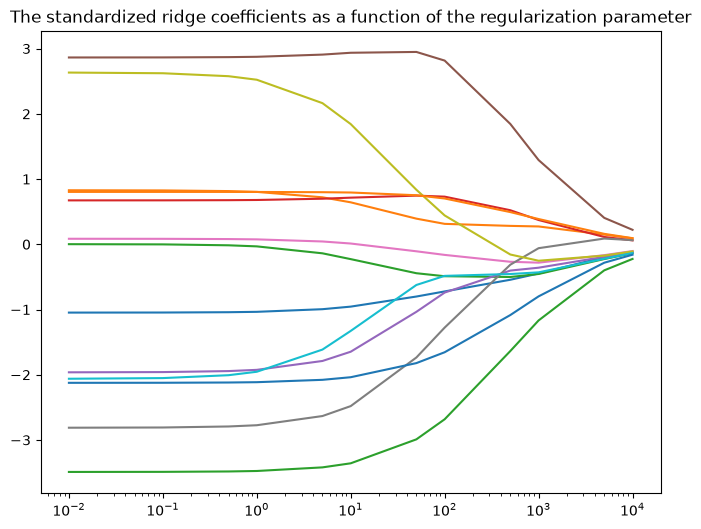

In [13]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.title("The standardized ridge coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

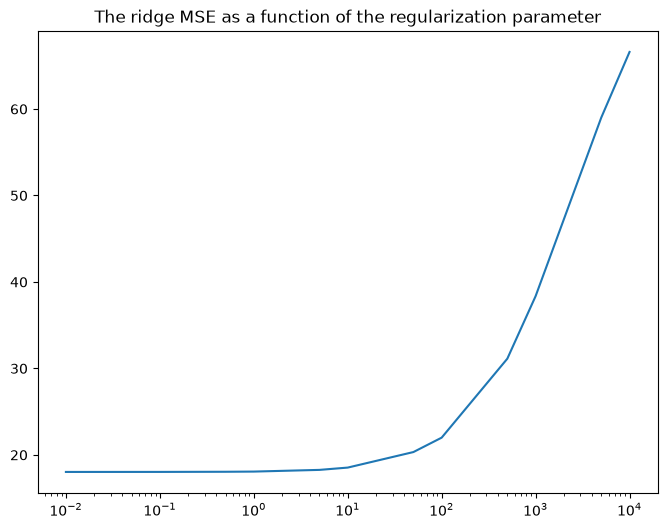

In [14]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs)
ax.set_xscale("log")
plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### [```sklearn.linear_model.Lasso```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)를 이용한 예제

다음을 최소화한다.

minimize 1 / (2 * n_samples)) * ||y - Xw||^2_2 + alpha * ||w||_1

In [15]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 0.1) 
lasso.fit(X_tn_std, y_tn)
print(lasso.coef_, lasso.intercept_)

[-0.74566662  0.33636947 -0.22855192  0.68889549 -1.41096384  3.04855608
 -0.         -2.0418613   0.83373893 -0.43926123 -1.99634969  0.71742516
 -3.43493366] 22.412137203166267


In [16]:
L_coefs = []
L_errs = []

alphas = np.arange(0.1, 10, 0.1)

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_tn_std, y_tn)
    L_coefs.append(lasso.coef_)
    L_errs.append(mean_squared_error(y_te, lasso.predict(X_te_std)))

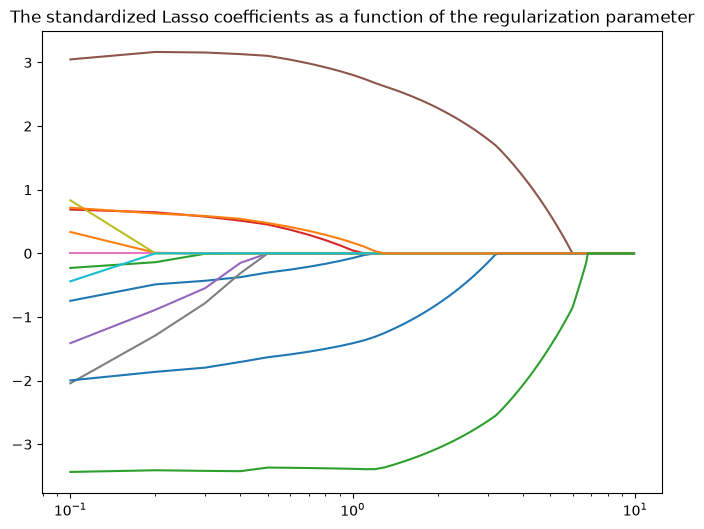

In [17]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_coefs)
ax.set_xscale("log")
plt.title("The standardized Lasso coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

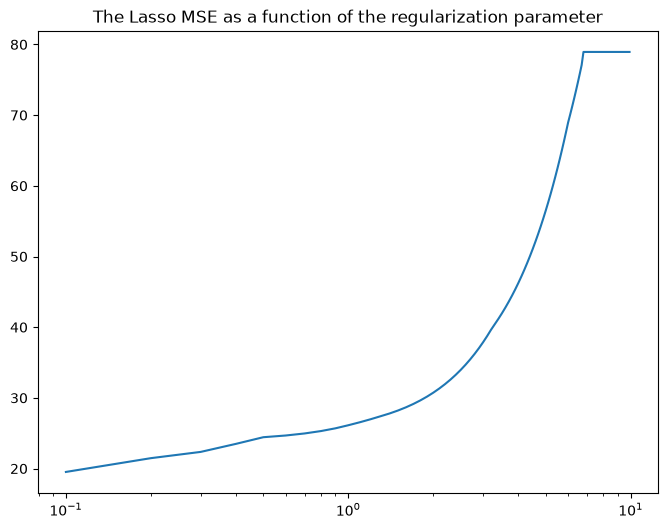

In [18]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_errs)
ax.set_xscale("log")
plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### with K-fold cross validation

앞 단원에서 공부했던 k-fold cross validation 방법을 다시 적용하여 보자.

In [19]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler

alphas = np.arange(0.01, 10, 0.01)

errs_alpha = [] # alpha별 에러

for a in alphas:
    
    kfold_errs = []  # 각 폴드 별 에러
    
    kf = KFold(n_splits = 5, shuffle=True, random_state=1)
    
    for train_index, test_index in kf.split(X):
    
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        std_scale = StandardScaler()
        std_scale.fit(X_train)
        
        X_train_std = std_scale.transform(X_train)
        X_test_std = std_scale.transform(X_test)
        
        ridge = Ridge(alpha = a)
        ridge.fit(X_train_std, y_train)
        
        kfold_errs.append(mean_squared_error(y_test, ridge.predict(X_test_std)))
        
    errs_alpha.append(np.mean(kfold_errs))

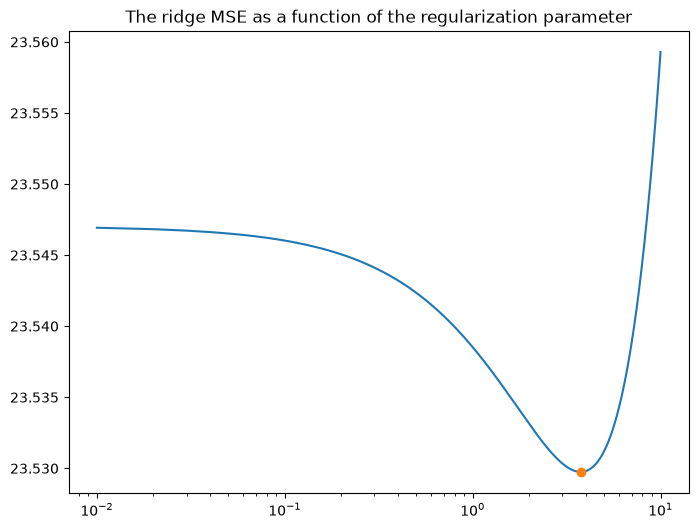

In [20]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

혹은 더 간단하게 `cross_val_score`를 이용한 버전을 살펴보자.

* 아래 코드에서  `'neg_mean_squared_error'`는 MSE의 음수값을 나타내므로, mse 평균을 구할 때는 다시 마이너스를 취한다.

* `cross_val_score` 함수의 기본 동작은 높은 값일수록 좋은 성능으로 간주하도록 되어 있어, 음의 평균 제곱 오차를 사용하도록 구현되어 있다.

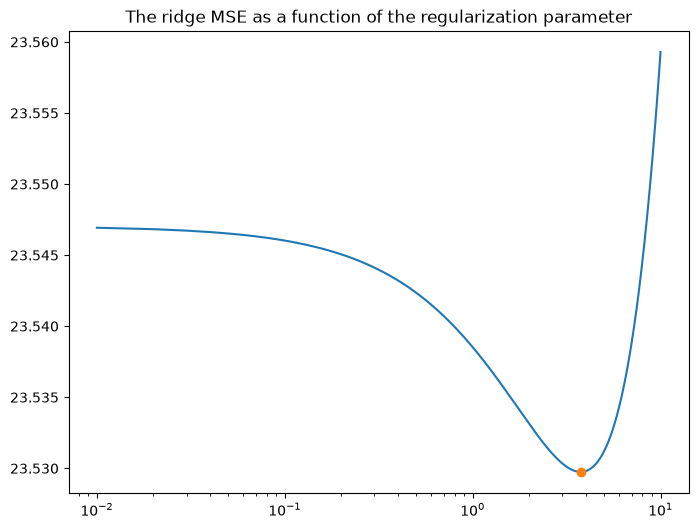

In [21]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# alpha 값들
alphas = np.arange(0.01, 10, 0.01)
errs_alpha = []
cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Lasso에 대해서도 비슷하게 해 보자.

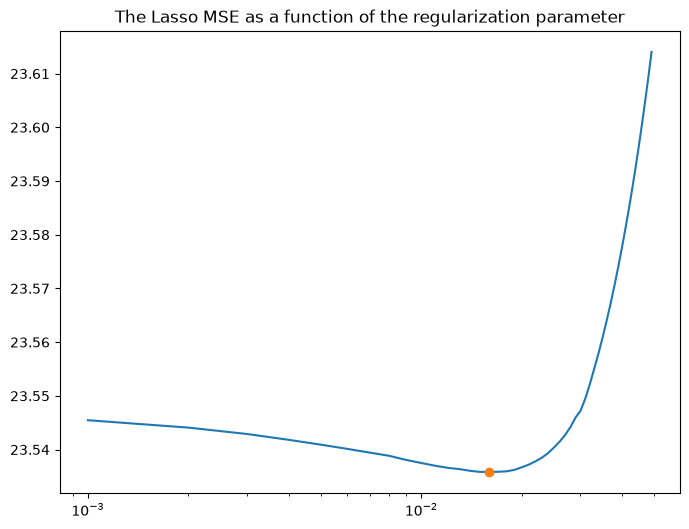

In [22]:

alphas = np.arange(0.001, 0.05, 0.001)
errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Lasso(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### sklearn에서의 ElasticNet

[```sklearn.linear_model.ElasticNet```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

minimize 1 / (2 * n_samples) * ||y - Xw||^2_2 + alpha * l1_ratio * ||w||_1 + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2

In [23]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elastic.fit(X_tn_std, y_tn)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [24]:
print(elastic.coef_, elastic.intercept_)

[-0.79608003  0.39900672 -0.32844799  0.71553512 -1.27195031  3.00505074
 -0.         -1.94841611  0.96784117 -0.63361775 -1.92814931  0.7425511
 -3.25731574] 22.412137203166267


In [25]:
ridge = Ridge(alpha=1).fit(X_tn_std, y_tn)
lasso = Lasso(alpha=0.1).fit(X_tn_std, y_tn)

pred_lr = lr.predict(X_te_std)
pred_ridge = ridge.predict(X_te_std)
pred_lasso = lasso.predict(X_te_std)
pred_elastic = elastic.predict(X_te_std)


In [26]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_te, pred_lr))
print(mean_squared_error(y_te, pred_ridge))
print(mean_squared_error(y_te, pred_lasso))
print(mean_squared_error(y_te, pred_elastic))

18.027910224668915
18.06977947226029
19.522467020145665
19.662900757339564


### Hitter example

여러 지표를 바탕으로 야구(타자) 선수의 연봉을 예측하는 문제

In [27]:
import pandas as pd
df = pd.read_csv('https://gist.githubusercontent.com/keeganhines/59974f1ebef97bbaa44fb19143f90bad/raw/d9bcf657f97201394a59fffd801c44347eb7e28d/Hitters.csv')
df = df.dropna(axis=0)
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N
5,-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,...,501,336,194,A,W,282,421,25,750.0,A


In [28]:
from sklearn.model_selection import train_test_split

y = df["Salary"]
X = df.iloc[:, 1:]
X = X.drop(["Salary", "League", "Division", "NewLeague"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [29]:
from sklearn.preprocessing import StandardScaler

std_scale = StandardScaler()
std_scale.fit(X_train)
X_train_std = std_scale.transform(X_train)
X_test_std = std_scale.transform(X_test)

In [30]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1)   
ridge.fit(X_train_std, y_train)
print(ridge.coef_, ridge.intercept_)

[-259.10754142  271.20662559   13.5602026   -52.11771231   15.7951181
  119.72132971  -52.40075435 -288.08864404  286.85059338  -22.17724389
  332.45206779  133.40434102 -208.61650869   83.13825717   50.83291066
  -28.42391401] 519.3865076142131


In [31]:
import numpy as np
from sklearn.metrics import mean_squared_error

alphas = np.array([0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000])

coefs = []
errs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_std, y_train)
    coefs.append(ridge.coef_)
    errs.append(mean_squared_error(y_test, ridge.predict(X_test_std)))

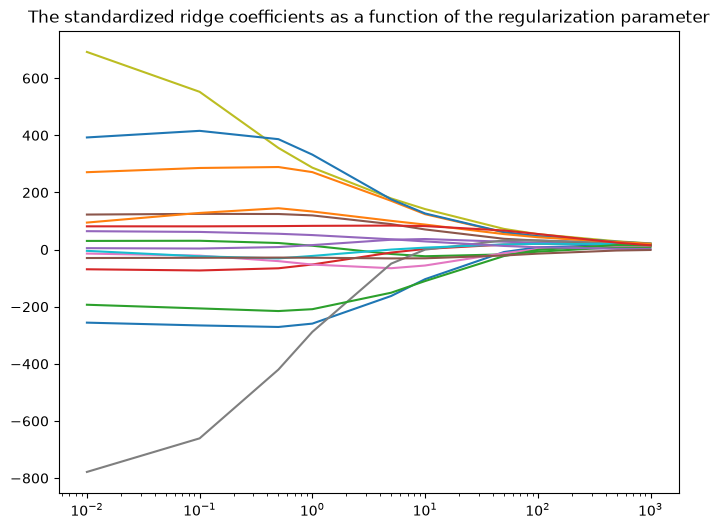

In [32]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.title("The standardized ridge coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

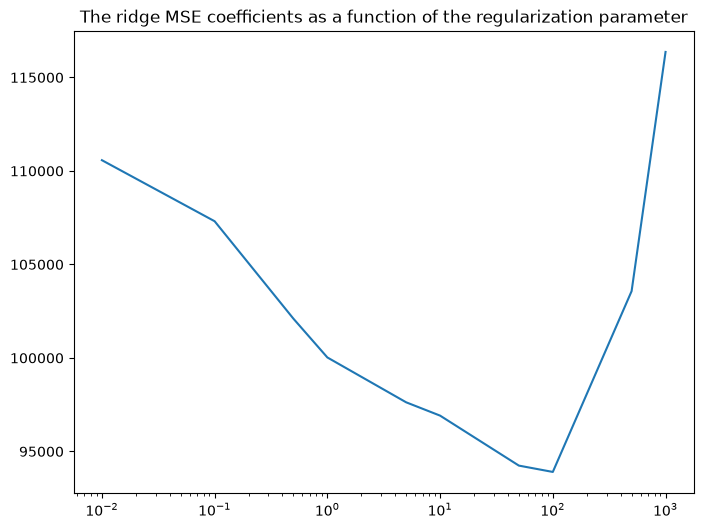

In [33]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs)
ax.set_xscale("log")
plt.title("The ridge MSE coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

In [34]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 1) 
lasso.fit(X_train_std, y_train)
print(lasso.coef_, lasso.intercept_)

[-246.87138369  251.09395195   11.53795529  -40.5450288    15.48239791
  113.93180684  -31.44082401 -493.82808102  488.80343138    0.
  326.1730461    89.71670312 -190.07101692   82.60845671   51.51590328
  -25.35418909] 519.3865076142131


In [35]:
L_coefs = []
L_errs = []

alphas = np.array([0.5, 1, 2.5, 5, 10, 25, 50, 100])

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=2000)
    lasso.fit(X_train_std, y_train)
    L_coefs.append(lasso.coef_)
    L_errs.append(mean_squared_error(y_test, lasso.predict(X_test_std)))

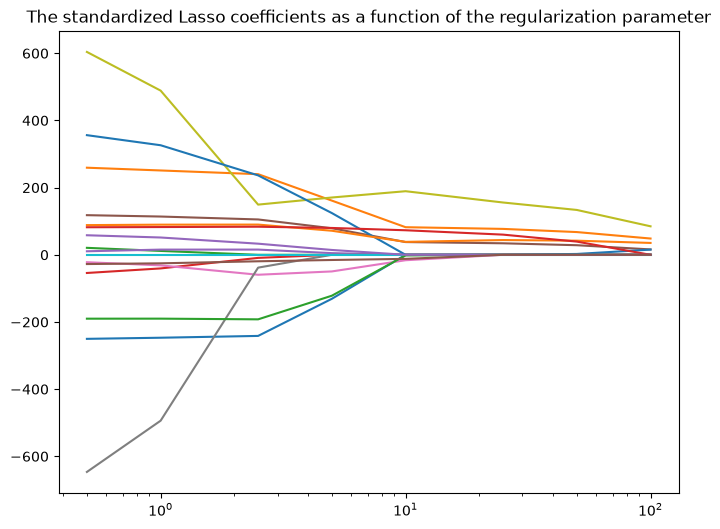

In [36]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_coefs)
ax.set_xscale("log")
plt.title("The standardized Lasso coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

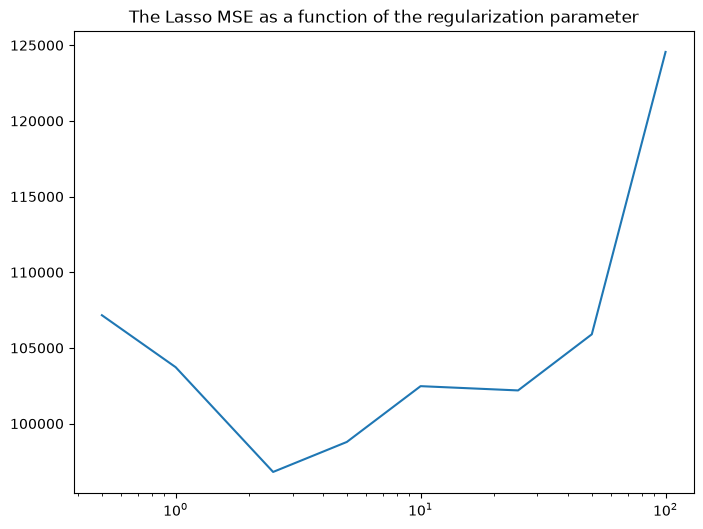

In [37]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_errs)
ax.set_xscale("log")
plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

#### With k-fold cross-validation

Ridge regression을 이용하여 앞에서 했던 내용을 반복해 보자.

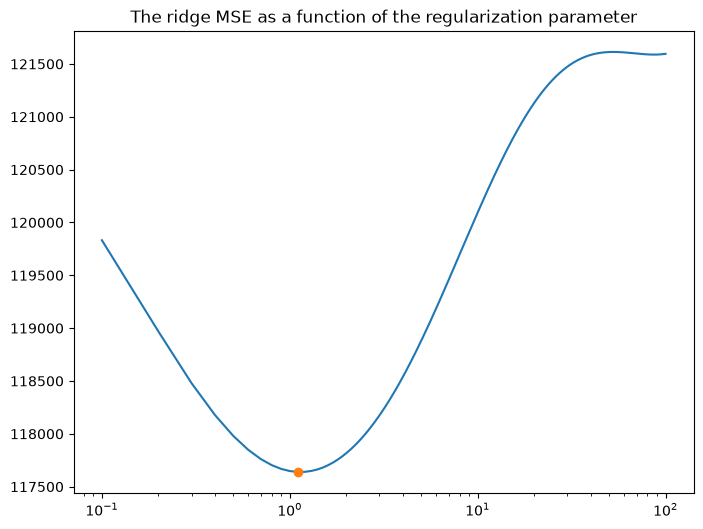

In [38]:
from sklearn.model_selection import KFold
alphas = np.arange(0.1, 100, 0.1)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Lasso regression을 이용하여 같은 방법을 다시 적용하여 보았다.

In [39]:
from sklearn.model_selection import KFold
alphas = np.arange(1, 10, 0.02)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Lasso(alpha=a, max_iter=2000))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


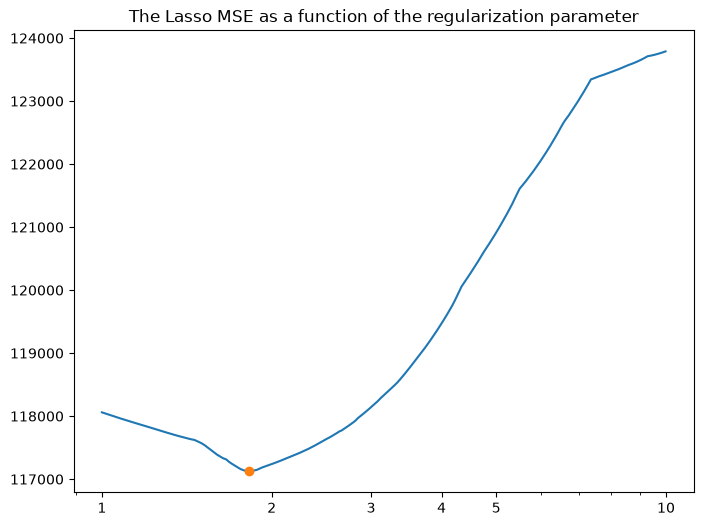

In [40]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')
plt.xticks([1, 2, 3, 4, 5, 10], ['1', '2', '3', '4', '5', '10'])

plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()